In [1]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import scipy

Creiamo ora una funzione per calcolare la log-densità di una distribuzione Gaussiana multivariata:

$$ \log \mathcal{N} (\mathbf{x}|\boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{M}{2} \log 2\pi - \frac{1}{2} \log |\boldsymbol{\Sigma}| - \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) $$

In [2]:
def logpdf_GAU_ND(x, mu, C):
    M=x.shape[0]
    XC = x - mu
    sign, logdet = np.linalg.slogdet(C)
    invC = np.linalg.inv(C)
    quad = np.sum(XC * (invC @ XC), axis=0)
    return -0.5 * (M * np.log(2*np.pi) + logdet + quad)

In [3]:
def vrow(vet):
    return vet.reshape((1, vet.size))

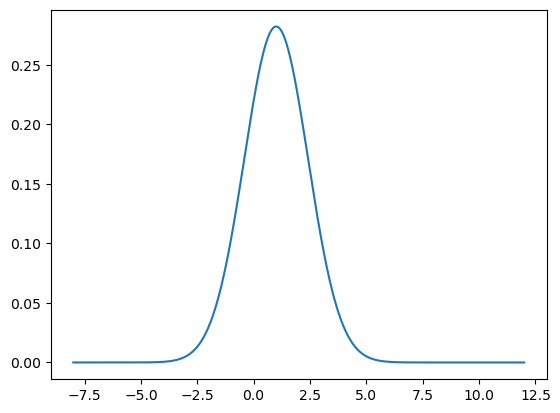

In [4]:
plt.figure()
XPlot = np.linspace(-8, 12, 1000)
m = np.ones((1,1)) * 1.0
C = np.ones((1,1)) * 2.0
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), m, C)))
plt.show()

In [5]:
def loglikelihood(XND, m_ML, C_ML):
    logpdf=logpdf_GAU_ND(XND,m_ML,C_ML)
    return np.sum(logpdf)

XND = np.load('npy/XND.npy')

m_ML = np.array([[-0.07187197], [0.05979594]])
C_ML = np.array([[0.94590166, 0.09313534], [0.09313534, 0.8229693]])

ll = loglikelihood(XND, m_ML, C_ML)
print(ll)


-270.70478023795056


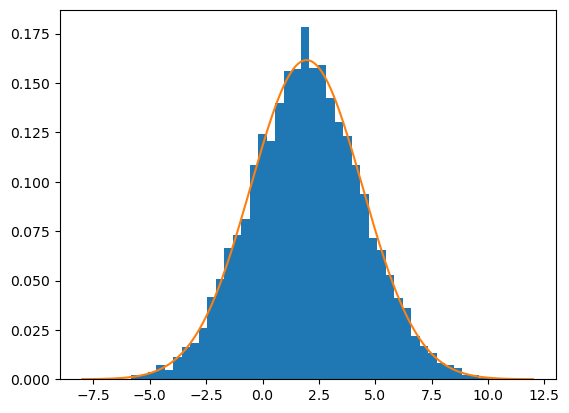

In [6]:

X1D = np.load('npy/X1D.npy')
m_ML = X1D.mean(axis=1, keepdims=True)
C_ML = ((X1D - m_ML) @ (X1D - m_ML).T) / X1D.shape[1]
plt.figure()
plt.hist(X1D.ravel(), bins=50, density=True)
XPlot = np.linspace(-8, 12, 1000)
plt.plot(XPlot.ravel(), np.exp(logpdf_GAU_ND(vrow(XPlot), m_ML, C_ML)))


In [7]:
ll = loglikelihood(X1D, m_ML, C_ML)
print(ll)

-23227.077654602715


Applichiamo ora quanto fatto all'Iris Dataset


In [8]:
def init_dataset():
    iris_dataset=load_iris()
    D=iris_dataset.data.T
    L=iris_dataset.target
    classes=iris_dataset.target_names
    features=iris_dataset.feature_names
    
    print(f"Le classi sono : {classes} e le features :{features}")
    
    return D,L,classes,features

D,L,classes,features=init_dataset()

Le classi sono : ['setosa' 'versicolor' 'virginica'] e le features :['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [9]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=getCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]


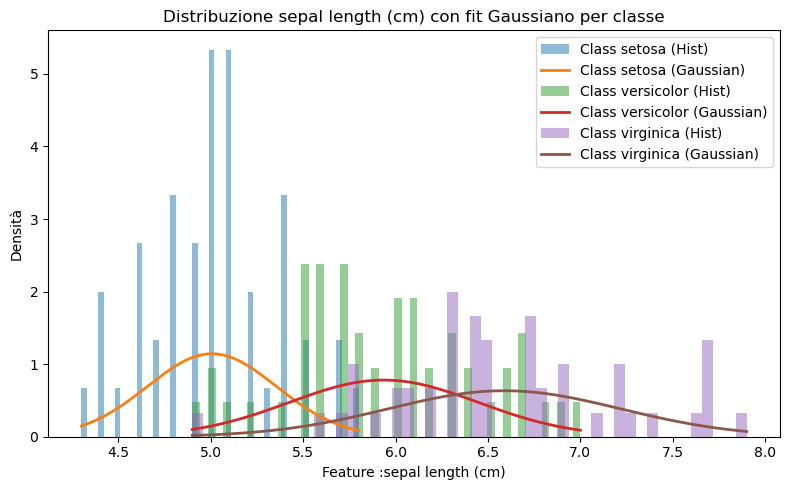

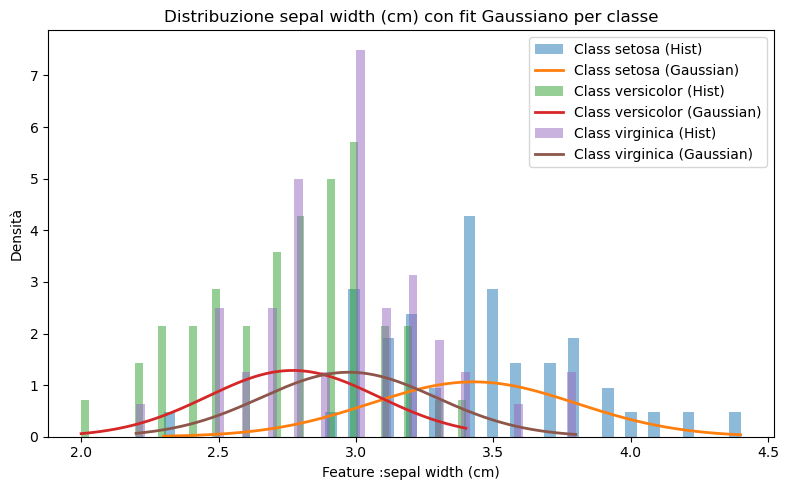

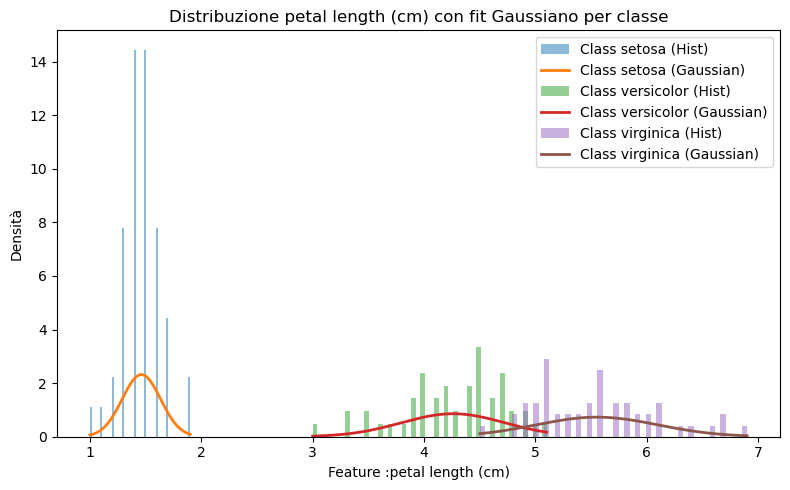

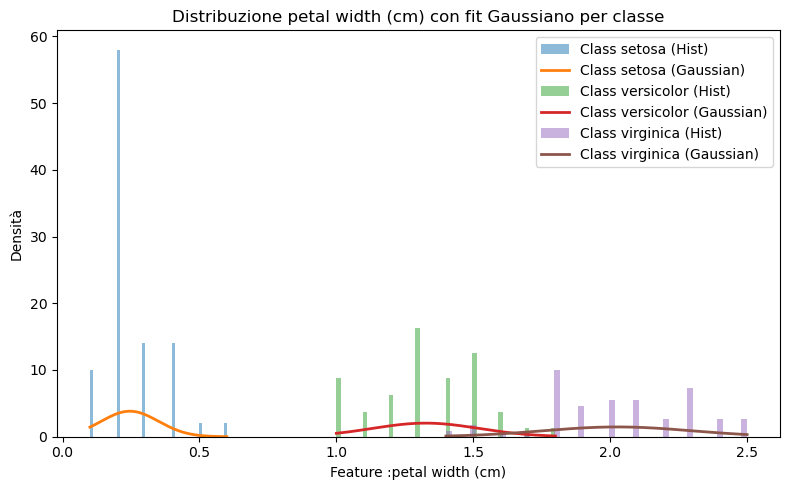

In [17]:
n_features = D.shape[0]
for i in range(n_features):
    plt.figure(figsize=(8, 5))

    for cnt in range(len(classes)):
        mask = L == cnt
        D0 = getRow(D[i, mask])
        mu = getMu(D0)
        C = getC(D0)

        # 1. Disegna l'istogramma
        plt.hist(D0.ravel(), bins=50, density=True, alpha=0.5, label=f'Class {classes[cnt]} (Hist)')

        # 2. Crea un asse X ordinato che va dal minimo al massimo dei tuoi dati per disegnare la curva
        XPlot = np.linspace(D0.min(), D0.max(), 1000)

        # 3. Calcola la log-densità su XPlot (ricorda di usare vRow) ed esponenziala
        pdf_values = np.exp(logpdf_GAU_ND(getRow(XPlot), mu, C))

        # 4. Disegna la curva Gaussiana
        plt.plot(XPlot.ravel(), pdf_values.ravel(), linewidth=2, label=f'Class {classes[cnt]} (Gaussian)')

    plt.title(f'Distribuzione {features[i]} con fit Gaussiano per classe')
    plt.xlabel(f'Feature :{features[i]}')
    plt.ylabel('Densità')
    plt.legend()
    plt.tight_layout()
    plt.show()